In [590]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [591]:
df = pd.read_csv("boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


CRIM - per capita crime rate by town

ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS - proportion of non-retail business acres per town.

CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX - nitric oxides concentration (parts per 10 million)

RM - average number of rooms per dwelling

AGE - proportion of owner-occupied units built prior to 1940

DIS - weighted distances to five Boston employment centres

RAD - index of accessibility to radial highways

TAX - full-value property-tax rate per 10,000

PTRATIO - pupil-teacher ratio by town

B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

LSTAT - % lower status of the population

MEDV - Median value of owner-occupied homes in $1000's

In [593]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [594]:
df.shape

(506, 14)

In [595]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## numerical (discrete, continuous) ve categorical (nominal, ordinal, binary)

categorical: 

nominal: CHAS, ordinal: RAD


numerical için işlem yapacağız

In [597]:
categorical_features = ["CHAS", "RAD"]
## numerical_features = [feature for feature in df.columns if df[feature].dtypes != "O"]
numerical_features = []
for feature in df.columns:
    if feature not in categorical_features:
        numerical_features.append(feature)
numerical_features

['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [598]:
discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<25]

In [599]:
discrete_features

[]

hiç discrete feature yok, sadece continuous var ona göre analiz yapacağız

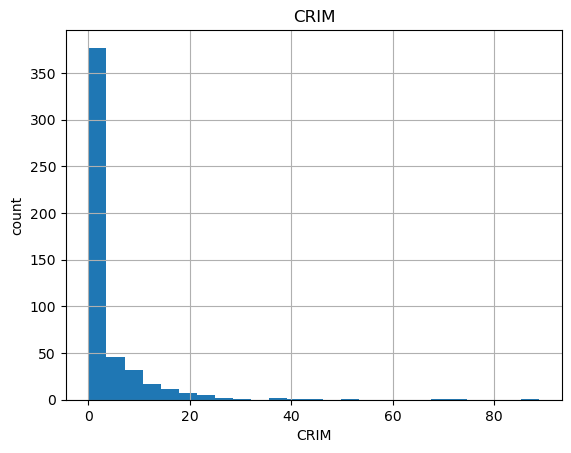

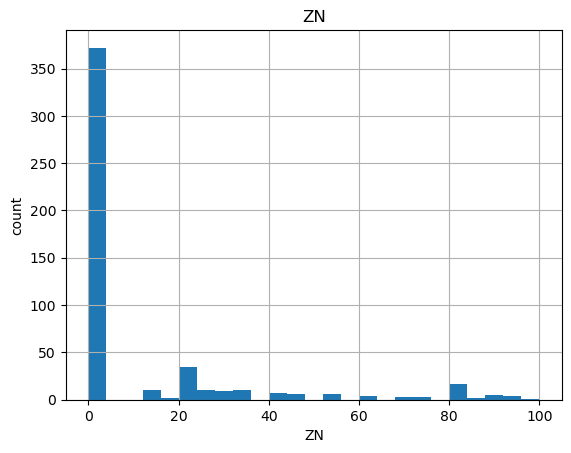

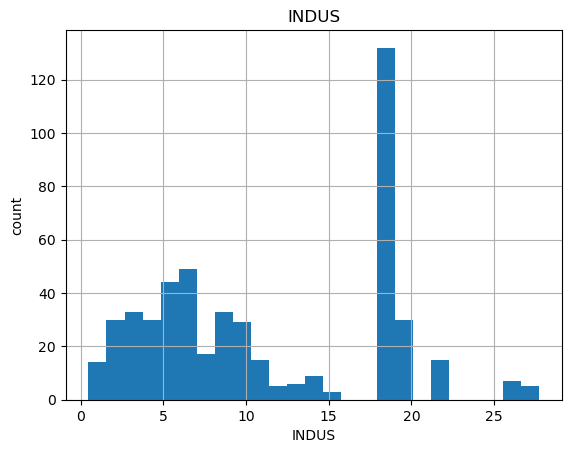

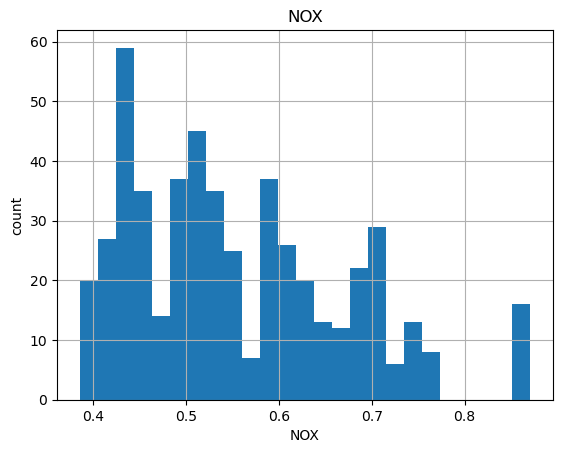

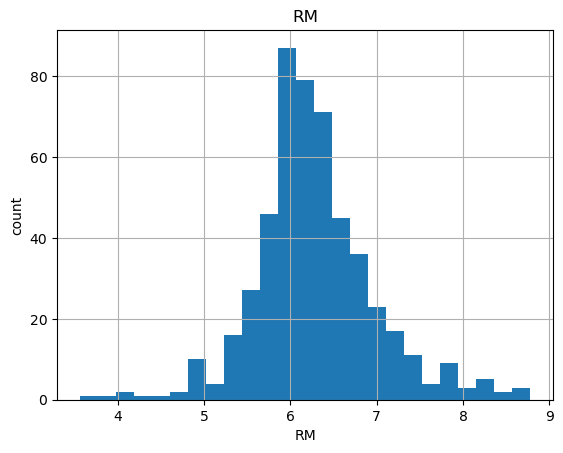

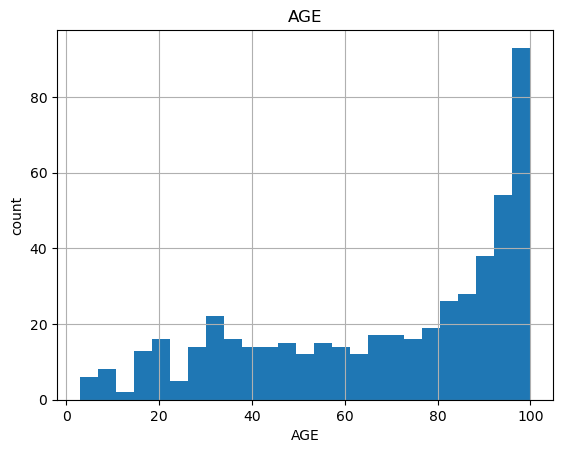

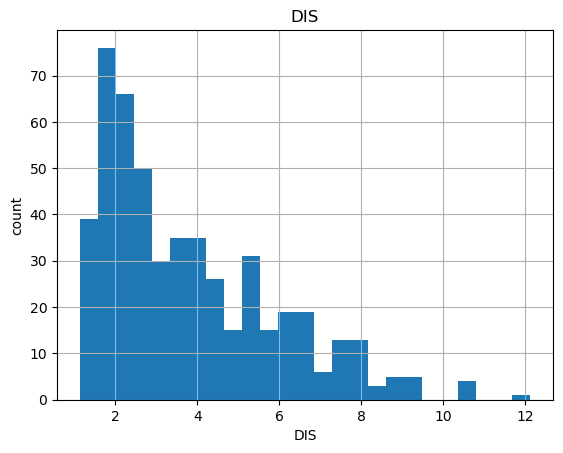

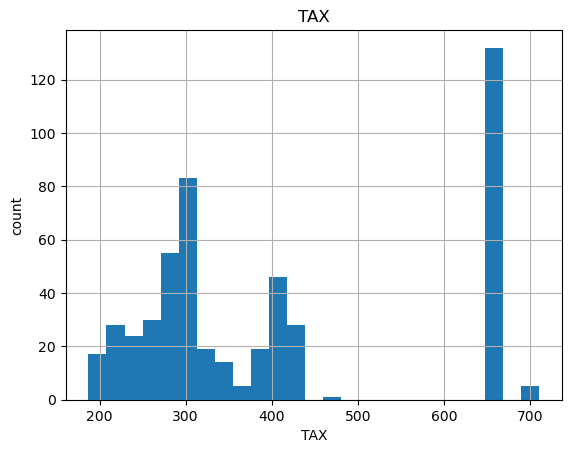

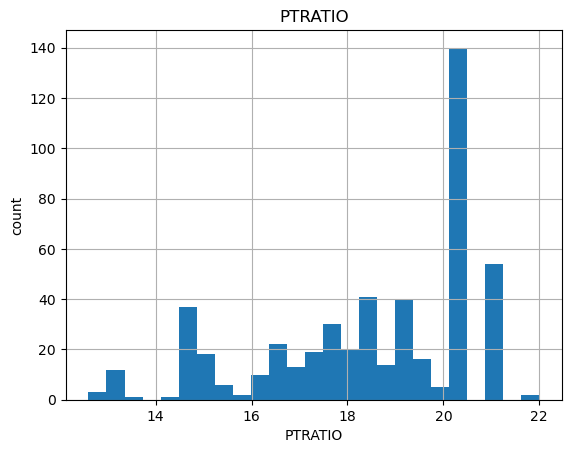

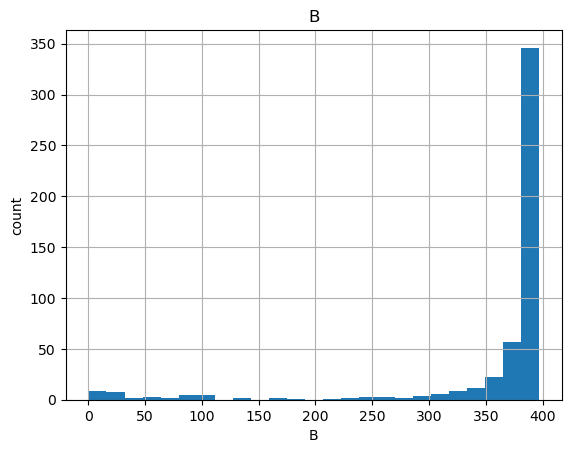

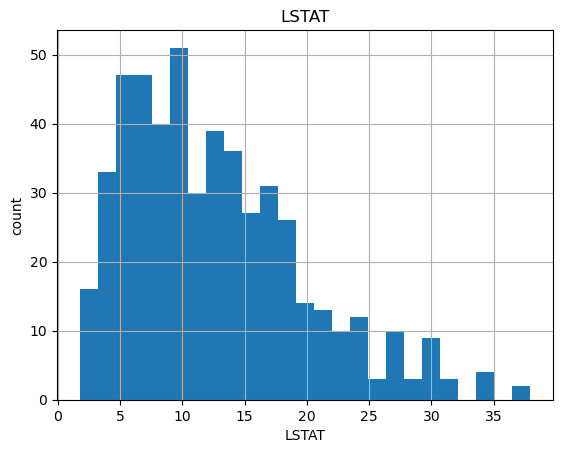

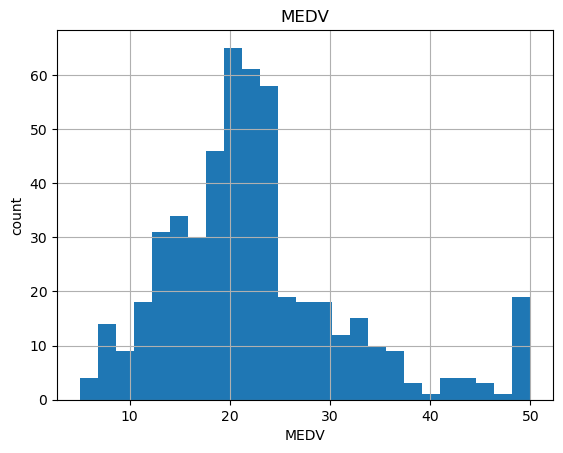

In [601]:
for feature in numerical_features:
    data = df.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.title(feature)
    plt.show()

çok fazla skewed dağılım var, transformation yapacağım

In [603]:
# for feature in numerical_features: 
#     data = df.copy()
#     if 0 in data[feature].unique(): 
#         pass
#     else: 
#         data[feature] = np.log(data[feature])
#         data["MEDV"] = np.log(data["MEDV"])
#         plt.scatter(data[feature], data["MEDV"])
#         plt.xlabel(feature)
#         plt.ylabel("MEDV")
#         plt.title(feature)
#         plt.show()

## Outliers

In [605]:
# for feature in numerical_features:
#     data = df.copy()
#     if 0 in data[feature].unique():  # log(0)=−∞ ve tanımsızdır (math error verir)
#         pass
#     else: 
#         data[feature] = np.log(data[feature])
#         data.boxplot(column=feature)
#         plt.ylabel(feature)
#         plt.title(feature)
#         plt.show()
    

In [606]:
for feature in numerical_features: 
    # data = df.copy()
    feature_std = np.std(df[feature])
    feature_mean = np.mean(df[feature])
    feature_zscore = (df[feature] - feature_mean) / feature_std
    # print(f"{feature} std: {feature_std}")
    # print(f"{feature} mean: {feature_mean}")
    # print(feature_zscore)
    # Outlier maskesi
    df = df[np.abs(feature_zscore) < 3]
    # if not outliers.empty:
    #     print(f"{feature} için outlier değerler:")
        # print(outliers[[feature]])
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


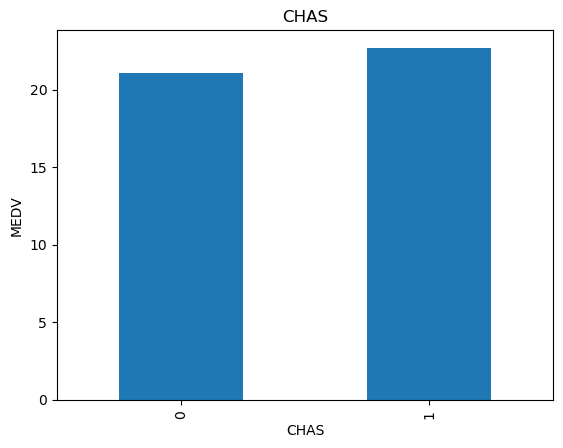

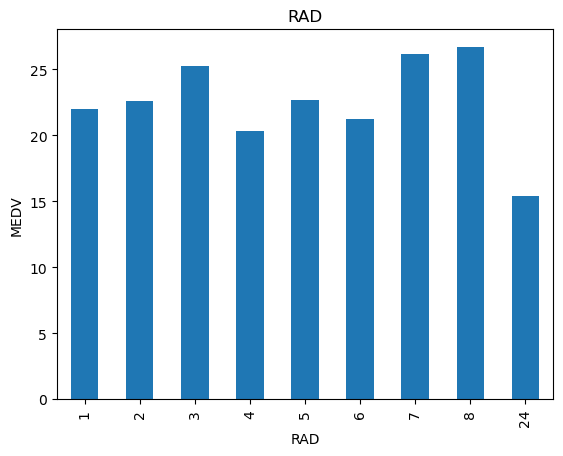

In [607]:
## Find out the relationship between categorical variable and dependent feature MEDV
for feature in categorical_features:
    data = df.copy()
    data.groupby(feature)["MEDV"].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel("MEDV")
    plt.title(feature)
    plt.show()

In [608]:
# data leakage riski olduğu için her zaman train test split yapılmalı 
# then apply feature engineering 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df ,df['MEDV'],test_size=0.1,random_state=0)

## scaling 

In [610]:
numerical_features

['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [611]:
for feature in numerical_features:
    if 0 in X_train[feature].unique(): 
        pass
    elif 0 in X_test[feature].unique(): 
        pass
    else: 
        X_train[feature] = np.log(X_train[feature])
        X_test[feature] = np.log(X_test[feature])
print(X_test.head())
print(X_train.head())

         CRIM    ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
164  0.807529   0.0  2.974509     0 -0.502527  1.767125  4.519612  0.884594   
463  1.761498   0.0  2.895912     0 -0.338274  1.873800  4.498698  1.030191   
54  -4.297685  75.0  1.386294     0 -0.891598  1.772916  3.862833  1.990569   
218 -2.201022   0.0  2.631169     1 -0.597837  1.783559  4.541165  1.061014   
10  -1.492144  12.5  2.063058     0 -0.646264  1.852698  4.546481  1.847935   

     RAD       TAX   PTRATIO         B     LSTAT      MEDV  
164    5  5.998937  2.687847  5.979164  2.454447  3.122365  
463   24  6.501290  3.005683  5.975894  2.331173  3.005683  
54     3  6.150603  3.049273  5.983684  2.694627  2.939162  
218    5  5.620401  2.797281  5.983684  2.885917  3.068053  
10     5  5.739793  2.721295  5.972587  3.017983  2.708050  
         CRIM    ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
15  -0.466187   0.0  2.096790     0 -0.619897  1.763703  4.034241  1.503766   
9

## nadir kategorileri "other" grubuna topla 

In [613]:
for feature in categorical_features: 
    temp = X_train.groupby(feature)["MEDV"].count() / len(X_train)
    print(temp)

CHAS
0    0.937984
1    0.062016
Name: MEDV, dtype: float64
RAD
1     0.043928
2     0.051680
3     0.082687
4     0.235142
5     0.219638
6     0.062016
7     0.041344
8     0.051680
24    0.211886
Name: MEDV, dtype: float64


In [614]:
for feature in categorical_features: 
    temp = X_train.groupby(feature)["MEDV"].count() / len(X_train)
    temp_df = temp[temp>0.01].index
    X_train[feature] = np.where(X_train[feature].isin(temp_df), X_train[feature], "Other")
X_train[X_train["CHAS"] == "Other"]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


In [615]:
X_train[["CHAS", "RAD"]] = X_train[["CHAS", "RAD"]].astype(int)

In [616]:
for feature in categorical_features: 
    labels_ordered = X_train.groupby(feature)["MEDV"].mean().sort_values().index
    mapping = {k:i for i,k in enumerate(labels_ordered)}
    X_train[feature] = X_train[feature].map(mapping)
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
15,-0.466187,0.0,2.096790,0,-0.619897,1.763703,4.034241,1.503766,1,5.726848,3.044522,5.980454,2.136531,2.990720
99,-2.679463,0.0,1.061257,0,-0.809681,2.003640,4.135167,1.251391,5,5.620401,2.890372,5.983684,1.822935,3.502550
63,-2.067513,25.0,1.635106,0,-0.791863,1.911319,3.770459,2.077051,8,5.648974,2.980619,5.980353,2.251292,3.218876
422,2.488915,0.0,2.895912,0,-0.487760,1.731302,4.472781,0.668445,0,6.501290,3.005683,5.675212,2.646175,3.034953
302,-2.378818,34.0,1.806648,0,-0.837018,1.871033,2.912351,1.703238,6,5.796058,2.778819,5.949626,2.159869,3.273364


## feature scaling - standard scaler 

In [618]:
feature_scale = [feature for feature in df.columns if feature not in ["CHAS", "RAD","MEDV"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[feature_scale] = scaler.fit_transform(X_train[feature_scale])
X_test[feature_scale] = scaler.fit_transform(X_test[feature_scale])
X_train, X_test

(         CRIM        ZN     INDUS  CHAS       NOX        RM       AGE  \
 15   0.278867 -0.499350 -0.050494     0  0.017671 -0.692177 -0.043162   
 99  -0.860131 -0.499350 -1.484906     0 -0.939969  1.920373  0.118188   
 63  -0.545208  0.794147 -0.690015     0 -0.850062  0.915136 -0.464869   
 422  1.799624 -0.499350  1.056443     0  0.684423 -1.044979  0.657932   
 302 -0.705413  1.259806 -0.452396     0 -1.077908  0.476482 -1.836728   
 ..        ...       ...       ...   ...       ...       ...       ...   
 357  1.212483 -0.499350  1.056443     1  1.826801  0.307533  0.718809   
 211  0.015091 -0.499350  0.313978     1 -0.464197 -1.525837  0.676079   
 121 -0.837744 -0.499350  1.539364     0  0.405664 -0.379427  0.592746   
 47  -0.239185 -0.499350 -0.277417     0 -0.906066 -0.332377  0.619141   
 183 -0.665770 -0.499350 -1.708054     0 -0.474526  0.589887  0.797646   
 
           DIS  RAD       TAX   PTRATIO         B     LSTAT      MEDV  
 15   0.543097    1 -0.416064  1.12922

## FEATURE SELECTION

## Variance Threshold

In [620]:
from sklearn.feature_selection import VarianceThreshold
var_thres = VarianceThreshold(threshold=0.01)
var_thres.fit(X_train)
var_thres.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [621]:
X_train = X_train.drop(["MEDV"], axis=1)

## Pearson Correlation

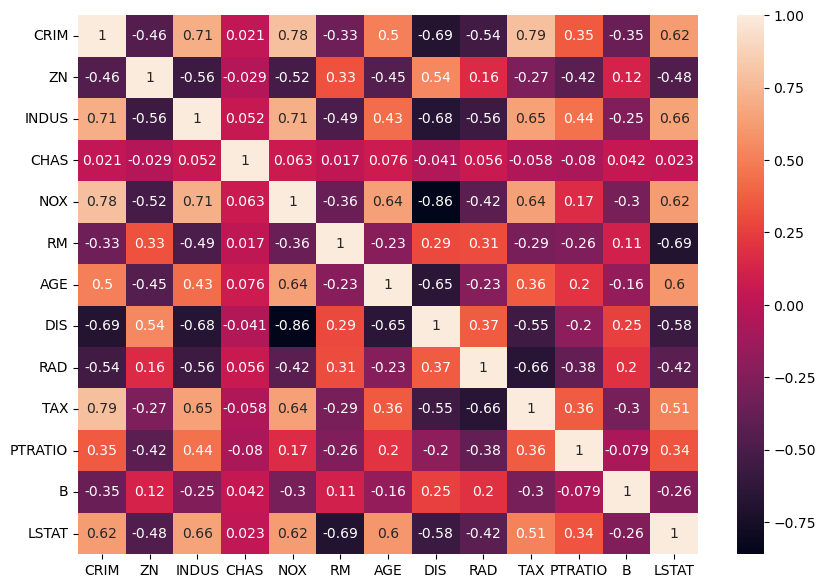

In [623]:
import seaborn as sns 
plt.figure(figsize=(10,7))
cor = X_train.corr()
sns.heatmap(cor, annot=True)
plt.show()

In [624]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [625]:
corr_features = correlation(X_train, 0.8)
corr_features

{'DIS'}

In [626]:
# X_train = X_train.drop(corr_features, axis=1)
# X_test = X_test.drop(corr_features, axis=1)

## Mutual Info

In [628]:
# from sklearn.feature_selection import mutual_info_regression
# mutual_info = mutual_info_regression(X_train, y_train)
# mutual_info

In [629]:
# from sklearn.feature_selection import SelectKBest
# selected_top_columns = SelectKBest(mutual_info_regression, k=7)
# selected_top_columns.fit(X_train, y_train)
# mutual_columns = X_train.columns[selected_top_columns.get_support()]
# mutual_columns

In [630]:
# not_mutual = [column for column in X_train.columns if column not in mutual_columns]

In [631]:
# X_train = X_train.drop(not_mutual, axis=1)
# X_test = X_test.drop(not_mutual, axis=1)

## MULTIPLE LINEAR REGRESSION 

In [633]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [634]:
X_test = X_test.drop(["MEDV"], axis=1)

## METRICS

In [636]:
# MSE, RMSE, MAE , R2
from sklearn.metrics import mean_squared_error
y_pred = reg.predict(X_test)
mean_squared_error(y_test, y_pred)

12.193720162124613

In [637]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.7692341236315853

In [638]:
N = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1-r2)*(N-1)/(N-p-1)
adjusted_r2

0.6692355772052723

## GRADIENT DESCENT
bu şekilde değil de sıfırdan başlayıp yapmak gerekiyor
sklearn’den aldığın katsayılarla gradient descent’i başlatırsan → sonuçlar bozulur, çünkü optimumdan uzaklaşırsın.

In [640]:
X_test.shape

(44, 13)

In [641]:
reg.coef_

array([ 0.91806592, -0.45420614, -0.66685368,  2.09861736, -1.49057221,
        2.18677285, -0.16881199, -1.6640992 ,  0.13799976, -0.99788273,
       -1.4326611 ,  0.34243861, -3.25181649])

In [642]:
reg.intercept_

21.446908142226295

In [643]:
def loss(yhat, y):
    L = 1/m * np.sum(np.power(yhat - y, 2))
    return L

In [1]:
# w = coefficients
# (m x n) dot  (m x 1).T
def gradient_descent(w, X, y, epochs=1000, learning_rate=0.01):
    m = X.shape[0]
    for i in range(epochs):
        yhat = np.dot(X, w)
        dLdw = (2/m) * np.dot(X.T, (yhat - y))
        w = w - learning_rate * dLdw
        L = (1/m) * np.sum(np.power(yhat - y, 2))
        if i % 100 == 0:  # her 100 adımda yazdır
            print(f"Epoch {i}, Loss: {L}")
    return w

# ridge regression
# def gradient_descent_ridge(w, X, y, lambd=0.1, epochs=1000, learning_rate=0.01):
#     m = X.shape[0]
#     for i in range(epochs):
#         yhat = np.dot(X, w)
#         # Gradient: klasik + ridge terimi
#         dLdw = (2/m) * np.dot(X.T, (yhat - y)) + 2 * lambd * w
#         w = w - learning_rate * dLdw
        
#         # Loss: klasik + ridge cezası
#         L = (1/m) * np.sum(np.power(yhat - y, 2)) + lambd * np.sum(w**2)
#         if i % 100 == 0:
#             print(f"Epoch {i}, Loss: {L}")
#     return w

In [730]:
# Train ve test'e bias (1'ler kolonu) ekle
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias  = np.c_[np.ones(X_test.shape[0]), X_test]


coef = reg.coef_ 
# w'yi de bias dahil olacak şekilde başlat
w_init = np.zeros(X_train_bias.shape[1])   # (14,)

w = gradient_descent(w_init, X_train_bias, y_train)

Epoch 0, Loss: 533.163953488372
Epoch 100, Loss: 47.28051911321086
Epoch 200, Loss: 24.510071159150836
Epoch 300, Loss: 16.106428406812185
Epoch 400, Loss: 12.694527159965768
Epoch 500, Loss: 11.259974100894961
Epoch 600, Loss: 10.638256670148763
Epoch 700, Loss: 10.360267821521692
Epoch 800, Loss: 10.231831376480388
Epoch 900, Loss: 10.170418094888042


In [731]:
y_pred = np.dot(X_test_bias, w)

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
N = X_test_bias.shape[0]
p = X_test_bias.shape[1] - 1   # bias hariç feature sayısı
adjusted_r2 = 1 - (1-r2)*(N-1)/(N-p-1)

mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("Adjusted R2:", adjusted_r2)
print("MSE:", mse)


R2: 0.7191835762068737
Adjusted R2: 0.5974964592298522
MSE: 14.838402204645236
